# EEG preprocessing demonstration

This notebook demonstrates one subject/session only. It loads a BDF recording, validates metadata, filters the signal, creates event-aligned windows, checks segment quality, and saves a portable processed archive.

In [26]:
from pathlib import Path
import importlib
import json
import sys
import mne

repo_root = Path.cwd()
if not (repo_root / 'src').is_dir():
    repo_root = repo_root.parents[1]
sys.path.insert(0, str(repo_root))

import src.preprocessing.filters as filters_module
importlib.reload(filters_module)

from src.anomaly_detection.detect_anomalies import detect_anomalies
from src.preprocessing.filters import FilterConfig, filter_raw
from src.preprocessing.load_data import load_bdf
from src.preprocessing.pipeline import ProcessedRecording, save_processed_segments
from src.preprocessing.segmentation import segment_recording

## Select one recording

Keep this first demonstration limited to one BDF. Update `dataset_root` if the extracted dataset is stored elsewhere.

In [27]:
dataset_root = Path(r'c:\Users\Shanmukha\Desktop\v1.0.0')
bdf_files = sorted(dataset_root.rglob('*_eeg.bdf'))
if not bdf_files:
    raise FileNotFoundError(f'No *_eeg.bdf files found under {dataset_root}')
bdf_path = bdf_files[0]
metadata_path = bdf_path.with_suffix('.json')
events_path = bdf_path.with_name(bdf_path.name.replace('_eeg.bdf', '_events.tsv'))
subject_id = next(part for part in bdf_path.parts if part.startswith('sub-'))
session_id = next(part for part in bdf_path.parts if part.startswith('ses-'))
print('BDF:', bdf_path)
print('Subject/session:', subject_id, session_id)
print('Sidecars:', metadata_path, events_path)

BDF: c:\Users\Shanmukha\Desktop\v1.0.0\sub-1\ses-1\eeg\sub-1_ses-1_task-rstate_run-0_eeg.bdf
Subject/session: sub-1 ses-1
Sidecars: c:\Users\Shanmukha\Desktop\v1.0.0\sub-1\ses-1\eeg\sub-1_ses-1_task-rstate_run-0_eeg.json c:\Users\Shanmukha\Desktop\v1.0.0\sub-1\ses-1\eeg\sub-1_ses-1_task-rstate_run-0_events.tsv


## Load and inspect metadata/events

In [28]:
loaded = load_bdf(
    bdf_path,
    metadata_path=metadata_path,
    events_path=events_path,
    preload=False,
)
print(loaded.metadata)
print('Channels:', loaded.metadata.channel_names)
print('Events:', len(loaded.events))
print('Conditions:', sorted({event.trial_type for event in loaded.events}))
print('First event:', loaded.events[0] if loaded.events else 'No events found')

Extracting BDF parameters from c:\Users\Shanmukha\Desktop\v1.0.0\sub-1\ses-1\eeg\sub-1_ses-1_task-rstate_run-0_eeg.bdf...
Setting channel info structure...
Creating raw.info structure...
RecordingMetadata(sampling_frequency=500.0, eeg_channel_count=61, channel_names=('Fp1', 'Fz', 'F3', 'F7', 'FT9', 'FC5', 'FC1', 'C3', 'T7', 'CP5', 'CP1', 'Pz', 'P3', 'P7', 'O1', 'Oz', 'O2', 'P4', 'P8', 'CP6', 'CP2', 'FCz', 'C4', 'T8', 'FT8', 'FC6', 'FC2', 'F4', 'F8', 'Fp2', 'AF7', 'AF3', 'AFz', 'F1', 'F5', 'FT7', 'FC3', 'C1', 'C5', 'TP7', 'CP3', 'P1', 'P5', 'PO7', 'PO3', 'POz', 'PO4', 'PO8', 'P6', 'P2', 'CPz', 'CP4', 'TP8', 'C6', 'C2', 'FC4', 'FT10', 'F6', 'AF8', 'AF4', 'F2'), duration_seconds=477.0)
Channels: ('Fp1', 'Fz', 'F3', 'F7', 'FT9', 'FC5', 'FC1', 'C3', 'T7', 'CP5', 'CP1', 'Pz', 'P3', 'P7', 'O1', 'Oz', 'O2', 'P4', 'P8', 'CP6', 'CP2', 'FCz', 'C4', 'T8', 'FT8', 'FC6', 'FC2', 'F4', 'F8', 'Fp2', 'AF7', 'AF3', 'AFz', 'F1', 'F5', 'FT7', 'FC3', 'C1', 'C5', 'TP7', 'CP3', 'P1', 'P5', 'PO7', 'PO3', 'POz'

## Visualize raw EEG

The interactive plot may open in a separate window depending on the notebook backend.

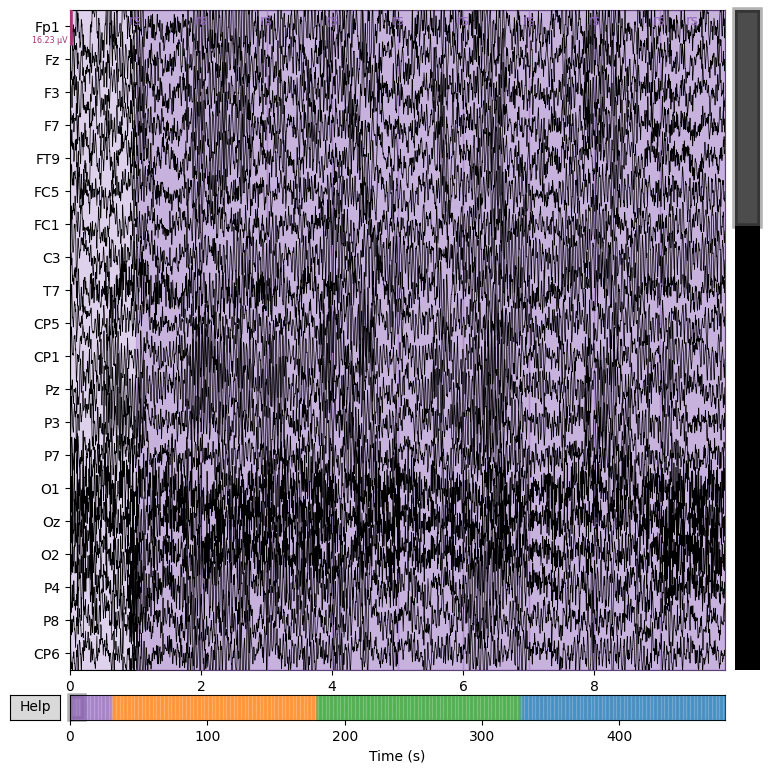

In [29]:
loaded.raw.plot(duration=10, n_channels=20, scalings='auto', block=False);

## Filter the recording

The project defaults are a 1-40 Hz band-pass and an optional 50 Hz notch for the dataset's stated power-line frequency. Filtering returns a copy.

Reading 0 ... 238499  =      0.000 ...   476.998 secs...


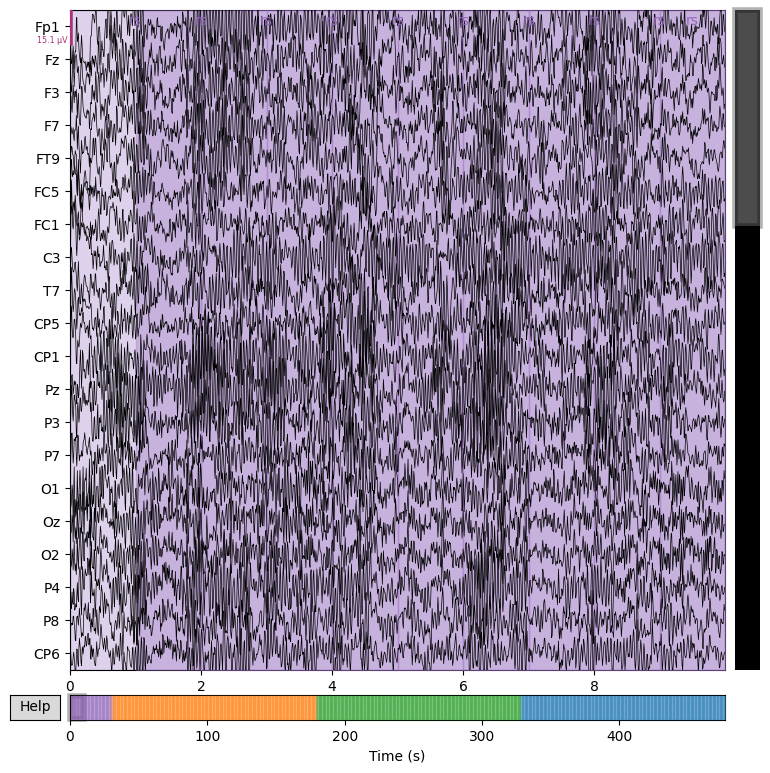

In [30]:
filter_config = FilterConfig(low_cutoff=1.0, high_cutoff=40.0, notch_frequency=50.0)
filtered_raw = filter_raw(loaded.raw, config=filter_config, verbose=False)
filtered_raw.plot(duration=10, n_channels=20, scalings='auto', block=False);

## Segment by event condition

Two-second non-overlapping windows are used here. Windows remain inside their event, and every segment keeps its subject, session, condition, and timing metadata.

In [31]:
segments = segment_recording(
    filtered_raw,
    loaded.events,
    subject_id=subject_id,
    session_id=session_id,
    window_duration=2.0,
    overlap=0.0,
)
print('Segments:', len(segments))
print('First segment:', segments[0] if segments else 'No complete windows found')
print('Labels:', [segment.condition for segment in segments[:10]])

Segments: 475
First segment: EEGSegment(data=array([[-1.09218783e-06, -2.33156829e-06, -3.82577417e-06, ...,
         2.53149617e-06,  1.53680835e-06,  7.75155414e-07],
       [-1.27648816e-06, -2.62987749e-06, -4.11745702e-06, ...,
        -7.05892342e-06, -6.60982766e-06, -6.05975238e-06],
       [-4.32635930e-07, -7.97822402e-07, -1.05508774e-06, ...,
        -1.14722349e-06, -2.03614473e-06, -3.00928395e-06],
       ...,
       [-5.54598433e-07, -1.29141644e-06, -2.34282399e-06, ...,
         3.29745382e-06,  2.54834135e-06,  1.66815274e-06],
       [-5.97779923e-08, -4.17535391e-07, -1.30425759e-06, ...,
        -1.05595335e-06, -9.49918399e-07, -8.91454471e-07],
       [ 9.00638002e-07,  1.54748962e-06,  1.72743960e-06, ...,
        -7.15211057e-06, -5.90554383e-06, -4.48042132e-06]],
      shape=(61, 1000)), subject_id='sub-1', session_id='ses-1', condition='rs', segment_id=0, start_seconds=0.002, end_seconds=2.002, sampling_frequency=500.0, channel_names=('Fp1', 'Fz', 'F3', 'F7

## Detect anomalous segments

Quality checks flag non-finite values, excessive amplitude/variance, and flat channels. Flagged segments are retained in the output for review.

In [32]:
anomalies = detect_anomalies(segments)
print('Normal segments:', len(anomalies.normal_segments))
print('Anomalous segments:', len(anomalies.anomalous_segments))
for report in anomalies.reports[:10]:
    if report.is_anomalous:
        print(report.segment_id, report.reasons)

Normal segments: 475
Anomalous segments: 0


## Save processed output

The compressed NumPy archive contains `data` with shape `(segments, channels, samples)` and a JSON metadata string for each segment. It is suitable for downstream EDA while retaining anomaly flags and reasons.

In [33]:
processed = ProcessedRecording(loaded, filtered_raw, segments, anomalies)
output_path = save_processed_segments(
    processed,
    repo_root / 'data' / 'processed' / f'{subject_id}_{session_id}_segments.npz',
)
print('Saved:', output_path)
print('Use np.load(output_path) to read data and metadata.')

Saved: c:\Users\Shanmukha\Desktop\eeg-cognitive-state-prediction\data\processed\sub-1_ses-1_segments.npz
Use np.load(output_path) to read data and metadata.
